# Concept Task Notebook

# Set up

Imports

In [1]:
# Standard library
import sys
import os
import random
from pathlib import Path

# Third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

# Local imports
PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
sys.path.append(str(PROJECT_ROOT))
from utils.shared.helpers import is_csv_valid
from utils.concept.helpers import build_universal_label_dict, compute_pos_weights

# Notebook tooling (Jupyter only)
%load_ext autoreload
%autoreload 2

Select device

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cpu


Paths

In [3]:
img_dir_path = PROJECT_ROOT / "data" / "dev_concept" / "images"
annotations_file_path = PROJECT_ROOT / "data" / "dev_concept" / "concepts.csv"
cui_to_name_path = PROJECT_ROOT / "data" / "cui_supplements" / "cui_inventory_names" / "cui_to_name_normal_2026.csv"
train_manual_path = PROJECT_ROOT / "data" / "cui_supplements" / "manuel_concepts" / "manuel_concepts" / "train_concepts_manual.csv"
valid_manual_path = PROJECT_ROOT / "data" / "cui_supplements" / "manuel_concepts" / "manuel_concepts" / "valid_concepts_manual.csv"

#TODO: get the paths dynamically instead of hardcoding them

CUI to Canoncial Name

In [4]:
cui_df = pd.read_csv(cui_to_name_path)
cui_to_name = dict(zip(cui_df["CUI"], cui_df["Name"]))
len(cui_to_name)

2646

Check that CSV is properly cleaned

In [5]:
is_csv_valid(annotations_file_path, verbose=True)


===== Column: ID =====
NaN count: 0
Empty/Whitespace count: 0
Leading/Trailing spaces: 0
Invalid split naming in ID: 0
No issues found.

===== Column: CUIs =====
NaN count: 0
Empty/Whitespace count: 0
Leading/Trailing spaces: 0
Spaces around ';': 0
Invalid CUI format: 0
Rows with ';;': 0
Rows with trailing ';': 0
Rows with empty labels: 0
Duplicate labels in row: 0
No issues found.


True

Create a universal label dictionary based on to standardize label mapping in datasets

In [6]:
label_dict = build_universal_label_dict(annotations_file_path)

# Dataset

Custom Dataset Class

In [7]:
class ConceptsDataset(Dataset):
    def __init__(self, csv_file, img_dir, label_dict, split, transform=None):
        allowed_splits = {"train", "valid", "test", "all"}

        if split not in allowed_splits:
            raise ValueError(
                f"Invalid split='{split}'. Must be one of {allowed_splits}"
            )

        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.label_dictionary = label_dict
        self.num_of_classes = len(self.label_dictionary)

        # train/val/test split
        if split != "all":
            self.data = self.data[self.data["ID"].str.contains(rf"_{split}_")].reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = os.path.join(self.img_dir, row["ID"] + ".jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Labels to multi-hot vector
        labels = row["CUIs"].split(";") # list of label strings
        target = torch.zeros(self.num_of_classes, dtype=torch.float32)

        for label in labels:
            target[self.label_dictionary[label]] = 1.0
        
        return image, target

Create a standard Transform 

In [8]:
from utils.concept.image_transforms import load_transforms

train_transform, val_test_transform = load_transforms()

#TODO: Check optimal resize
#TODO: Check for optimal normalization values (compute specific mean/std from dataset)
#TODO: Add data augmentation (random crop, horizontal flip, color jitter, etc.) (only for train_transform)

Create Train / Validation Datasets

In [9]:
train_ds = ConceptsDataset(annotations_file_path, img_dir_path, label_dict, split="train", transform=train_transform)
val_ds = ConceptsDataset(annotations_file_path, img_dir_path, label_dict, split="valid", transform=val_test_transform)

Create the loaders for each split

In [10]:
batch_size = 32
num_workers = 4

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    #pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    #pin_memory=True
)

Check some random samples

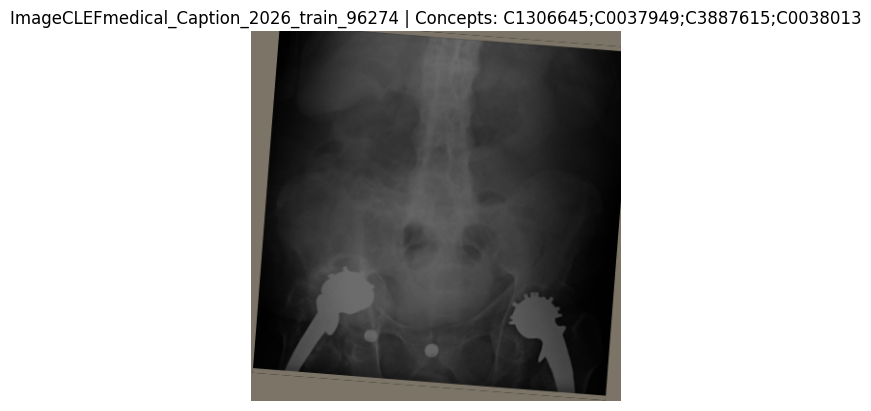

In [152]:
idx = random.randint(0, len(train_ds) - 1)
img, target = train_ds[idx]

row = train_ds.data.iloc[idx]
img_name = row["ID"]
cuis = row["CUIs"]

# If normalized, undo normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_vis = img * std + mean   # undo normalization

# Convert from CHW (C,H,W) to HWC for plot
img_vis = img_vis.permute(1, 2, 0).numpy()
img_vis = img_vis.clip(0,1)  # values [0,1]

plt.imshow(img_vis)
plt.title(f"{img_name} | Concepts: {cuis}")
plt.axis("off")
plt.show()

In [12]:
num_samples = 3

for _ in range(num_samples):
    idx = random.randint(0, len(train_ds) - 1)
    img, target = train_ds[idx]

    row = train_ds.data.iloc[idx]
    img_name = row["ID"]
    cuis = row["CUIs"]

    print(f"Image ID: {img_name}")
    print(f"CUIs: {cuis}")
    print(f"Image shape: {img.shape}")
    print(f"Multi-hot target: {target}")
    print(f"Number of labels: {int(target.sum())}")
    print("-" * 50)

Image ID: ImageCLEFmedical_Caption_2026_train_87708
CUIs: C1306645;C0000726;C1140618;C0019569
Image shape: torch.Size([3, 384, 384])
Multi-hot target: tensor([1., 0., 0.,  ..., 0., 0., 0.])
Number of labels: 4
--------------------------------------------------
Image ID: ImageCLEFmedical_Caption_2026_train_7043
CUIs: C0040405;C0006663;C0017651
Image shape: torch.Size([3, 384, 384])
Multi-hot target: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Number of labels: 3
--------------------------------------------------
Image ID: ImageCLEFmedical_Caption_2026_train_66859
CUIs: C0041618;C0030747
Image shape: torch.Size([3, 384, 384])
Multi-hot target: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Number of labels: 2
--------------------------------------------------


# Manual CUIs

train manual cuis

In [13]:
is_csv_valid(train_manual_path, verbose=False)

True

In [14]:
train_manual = pd.read_csv(train_manual_path)

cuis = set()
for entry in train_manual["CUIs"]:
    cuis.update(entry.split(";"))

train_cuis = cuis
print(len(train_cuis))

18


valid manual cuis

In [15]:
is_csv_valid(valid_manual_path, verbose=False)

True

In [16]:
valid_manual = pd.read_csv(valid_manual_path)

cuis = set()
for entry in valid_manual["CUIs"]:
    cuis.update(entry.split(";"))

valid_cuis = cuis
print(len(valid_cuis))

15


# Other checks

In [20]:
train_labels = set()
val_labels = set()

for row in train_ds.data["CUIs"]:
    train_labels.update(row.split(";"))

for row in val_ds.data["CUIs"]:
    val_labels.update(row.split(";"))

unknown_in_val = val_labels - train_labels

print("Labels in val not in train:", len(unknown_in_val))
print(unknown_in_val)

Labels in val not in train: 0
set()


In [21]:
pos_weights = compute_pos_weights(annotations_file_path, label_dict)

print("Min weight:", pos_weights.min())
print("Max weight:", pos_weights.max())
print("Mean weight:", pos_weights.mean())

Min weight: tensor(1.0454)
Max weight: tensor(10.)
Mean weight: tensor(8.1765)
